In [1]:
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytimetk as tk

import seaborn as sns
from scipy.stats import pearsonr
from sklearn.preprocessing import MaxAbsScaler
import xarray as xr

In [3]:
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100

%load_ext rich
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

The rich extension is already loaded. To reload it, use:
  %reload_ext rich
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Table of content
1. Data Preprocessing
2. Model Development
3. Model Training
4. Results

## 1. Data Preprocessing

#### List of tasks I did in this section. The cells are coming in the following order.  
- ✔️ Checked the sequence of weeks to be regular in time for the correct application of carryover, hence re-ordered the rows. 
- ✔️ Studied the number of zeros in "channel_spends" and reflected on whether they are 0 channel spends or missing entries and concluded.
- ✔️ Studied the missing weeks in the time sequence of each year and concluded.
- ✔️ Visualized diagram of "channel_spends" across time as well as "revenue" signal to create a visual understanding.
- ✔️ Created a table for the mean, median, std, ... of "channel_spends" to have a statistical understanding.
- ✔️ Performed Variance Inflation Factor (VIF) analysis and Correlation analysis to check for multicollinearity.
- ✔️ Added "black-friday" parameter to help the model grasp the giant peaks in "revenue" on those dates and have a more accurate "posterior predictive check". I also added "january-sale" similar to "black-friday" to grasp a couple of other outlier peaks in the revenue.

In [4]:
# Reading the data
df = pd.read_csv('MMM_test_data.csv', parse_dates=["start_of_week"]) \
    .assign(
        year      = lambda x: x["start_of_week"].dt.year,
        month     = lambda x: x["start_of_week"].dt.month,
        dayofyear = lambda x: x["start_of_week"].dt.dayofyear,
    ) \
    .reset_index() \
    [["index", "start_of_week", "year", "month", "dayofyear",
      "spend_channel_1", "spend_channel_2", "spend_channel_3",
      "spend_channel_4", "spend_channel_5", "spend_channel_6",
      "spend_channel_7", "revenue"]]

In [5]:
# Checking the sequence of weeks to be correctly ordered in time
print("Are rows initially in ascending order in time? ", df['start_of_week'].is_monotonic_increasing)
df = df.sort_values('start_of_week').reset_index(drop=True)
print("Are rows in ascending order in time after re-ordering? ", df['start_of_week'].is_monotonic_increasing)

Are rows initially in ascending order in time?  False
Are rows in ascending order in time after re-ordering?  True


In [6]:
spend_cols = ["spend_channel_1", "spend_channel_2", "spend_channel_3",
              "spend_channel_4", "spend_channel_5", "spend_channel_6",
              "spend_channel_7"]

zero_counts = (df[spend_cols] == 0).sum() \
    .reset_index() \
    .rename(columns={"index": "column_name", 0: "zero_count"})

print(zero_counts.to_string(index=False))

    column_name  zero_count
spend_channel_1          13
spend_channel_2           0
spend_channel_3           0
spend_channel_4           0
spend_channel_5           0
spend_channel_6          39
spend_channel_7           0


#### Comment: 
- Technically, the zeros should not be ignored and one should ask the client about the reason behind having them in the dataset. I am assuming that the zeros are not missing values and they are simply zero investments on those channels during those weeks. 

#### Comment: 
- This is an unbalanced panel — 2020 and 2022 are partial years, which creates problems; Seasonality terms in the model (Fourier features) will be affected by this since the model never sees a full cycle for years 2020 and 2022. 

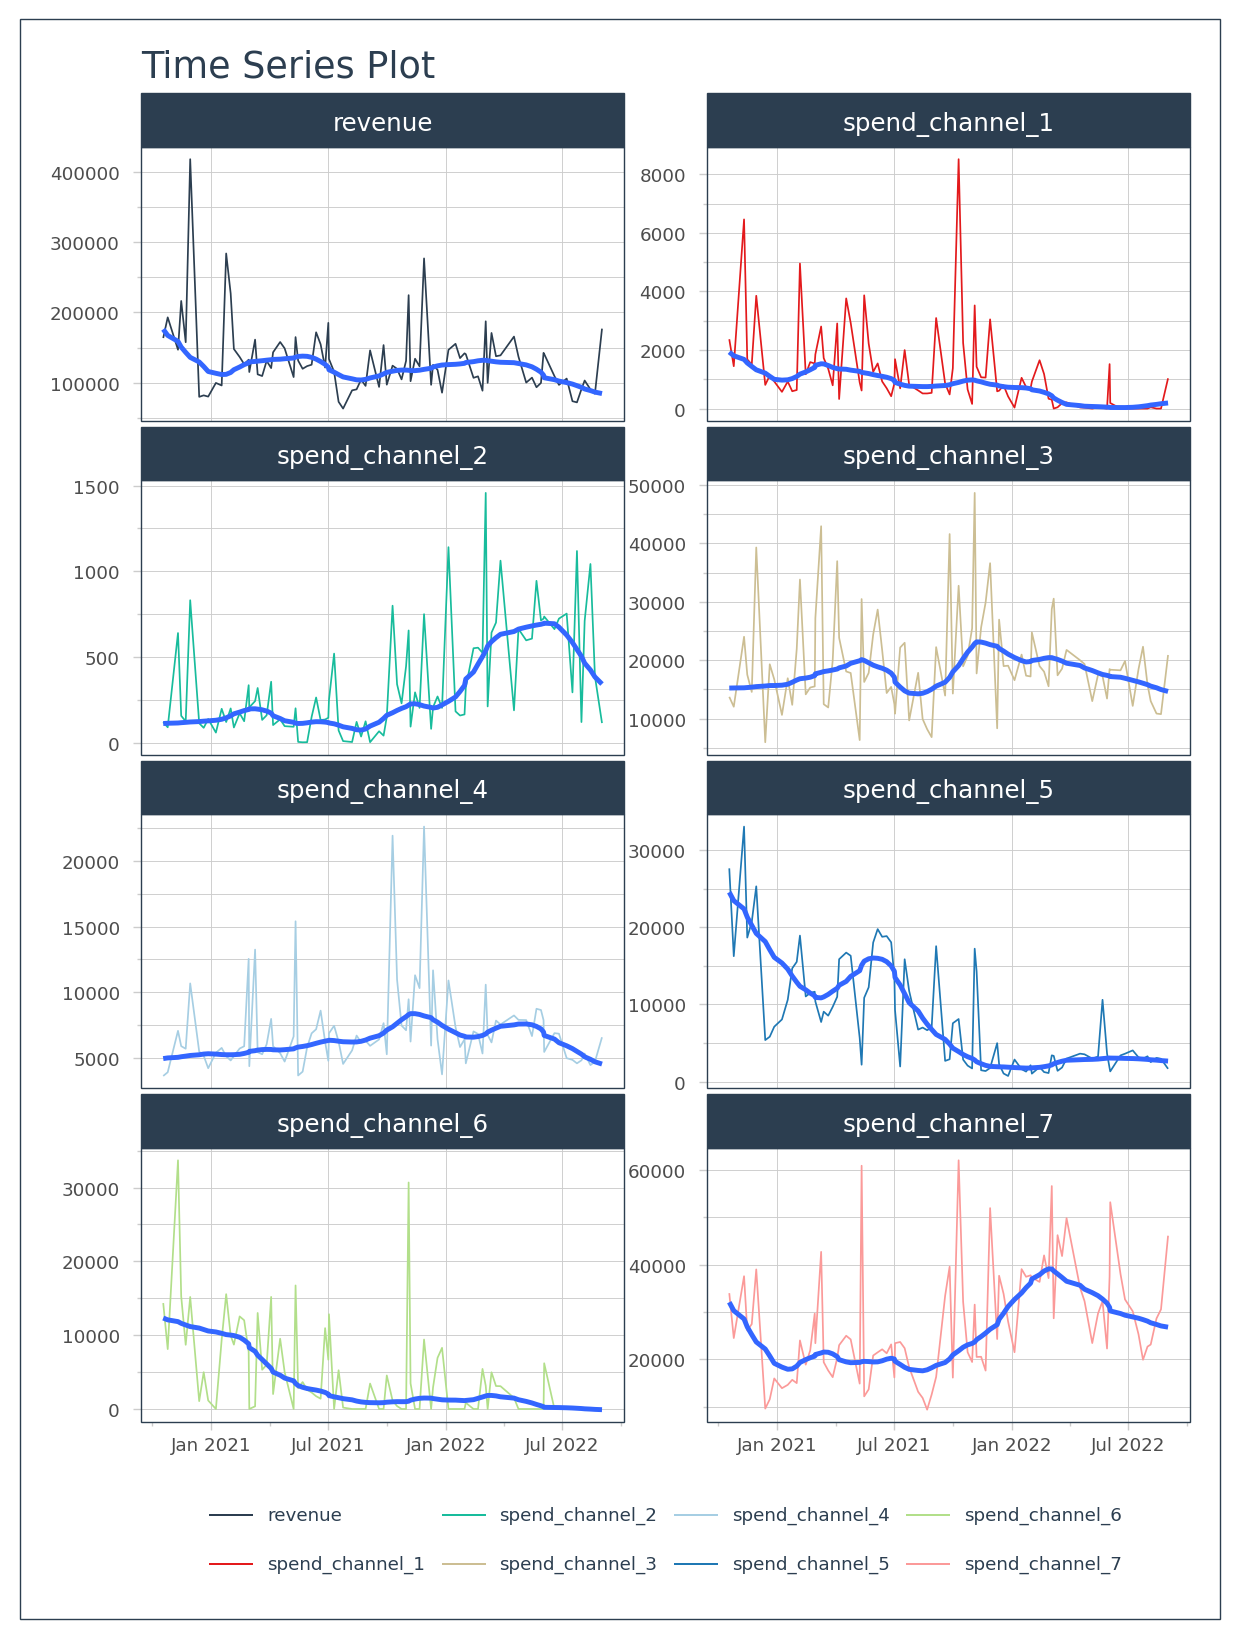

In [9]:
# Ploting the spends and the revenue time series 
spend_cols = [
    "spend_channel_1", "spend_channel_2", "spend_channel_3",
    "spend_channel_4", "spend_channel_5", "spend_channel_6",
    "spend_channel_7"
]

df_melted = df \
    .melt(
        id_vars=["start_of_week"],
        value_vars=["revenue"] + spend_cols
    ) \
    .groupby("variable")

display(
    tk.plot_timeseries(
        df_melted,
        date_column   = "start_of_week",
        value_column  = "value",
        color_column  = "variable",
        facet_ncol    = 2,
        width         = 600,
        height        = 800,
        legend_show   = False,
        engine        = "matplotlib"
    )
)
# The blue line is a smoothed trend line that tk.plot_timeseries() automatically adds

#### Comment: 
- we see that there are quite small amounts of spending on channel-2 compared to other channels. This is a point to remember in the interpretation of ROAS for channel-2. If channel-2 has correlation with other channels, it can "steal" credit from those channels and consequently have a large ROAS/ROI. 

In [10]:
# Total Spend and Revenue Basic Statistics Analysis
spend_cols = [
    "spend_channel_1", "spend_channel_2", "spend_channel_3",
    "spend_channel_4", "spend_channel_5", "spend_channel_6", "spend_channel_7"
]

total_spend   = df[spend_cols].sum(axis=0).sum()
total_revenue = df["revenue"].sum()

print(f"Total Spend:   ${total_spend:,.0f}")
print(f"Total Revenue: ${total_revenue:,.0f}")

# Ad Spend Analysis
median_spend = df[spend_cols].median()
mean_spend   = df[spend_cols].mean()

df[spend_cols] \
    .describe() \
    .apply(lambda x: x.apply(lambda y: "${:,.0f}".format(y)))

Total Spend:   $6,273,301
Total Revenue: $12,169,440


,spend_channel_1,spend_channel_2,spend_channel_3,spend_channel_4,spend_channel_5,spend_channel_6,spend_channel_7
count,$92,$92,$92,$92,$92,$92,$92
mean,"$1,211",$341,"$19,553","$7,033","$8,152","$4,364","$27,535"
std,"$1,418",$315,"$8,221","$3,181","$7,023","$6,354","$11,712"
min,$0,$4,"$5,938","$3,602",$747,$0,"$9,391"
25%,$319,$122,"$14,246","$5,298","$2,659",$0,"$19,430"
50%,$810,$203,"$18,050","$6,223","$5,746","$1,452","$24,102"
75%,"$1,540",$566,"$22,252","$7,557","$11,868","$6,739","$35,435"
max,"$8,514","$1,457","$48,647","$22,630","$33,010","$33,693","$61,984"


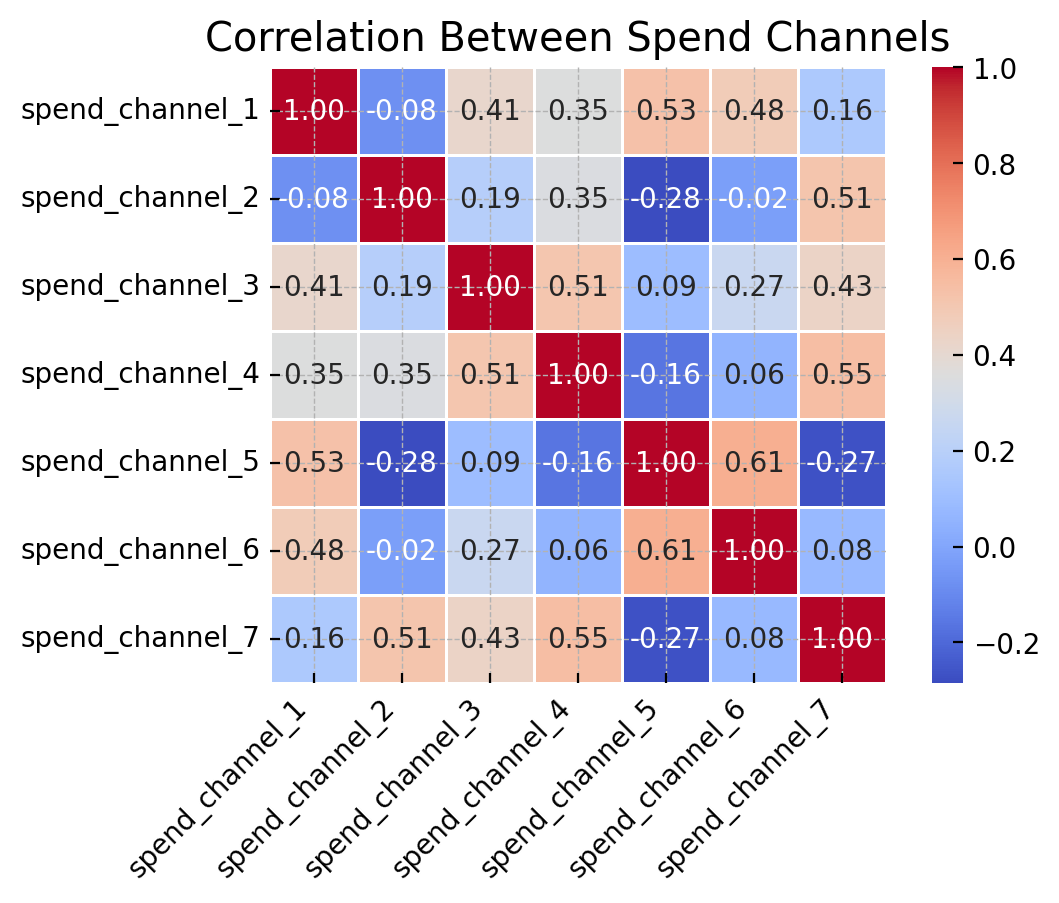

In [11]:
# * Spend Channel Correlation Analysis
spend_cols = [f"spend_channel_{i}" for i in range(1, 8)]
corr_matrix = df[spend_cols].corr()

# Print
# print(corr_matrix)

# Heatmap
plt.figure()
plt.close()
plt.figure(figsize=(6, 4));
sns.heatmap(
    corr_matrix,
    annot  = True,
    fmt    = ".2f",
    cmap   = "coolwarm",
    square = True,
    linewidths  = 0.5,
    linecolor   = "white"
)
plt.title("Correlation Between Spend Channels")
plt.xticks(rotation=45, ha="right")
plt.tight_layout
plt.show();

In [12]:
# Computing VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
cols = ['spend_channel_1','spend_channel_2','spend_channel_3','spend_channel_4','spend_channel_5','spend_channel_6','spend_channel_7']
X = df[cols]
vif_table = pd.DataFrame({'spend_channel': cols, 'VIF': [variance_inflation_factor(X.values, i) for i in range(len(cols))]})
print(vif_table)

     spend_channel        VIF
0  spend_channel_1   3.134400
1  spend_channel_2   3.176855
2  spend_channel_3   9.912802
3  spend_channel_4  10.392055
4  spend_channel_5   3.634702
5  spend_channel_6   2.544763
6  spend_channel_7  10.614603


#### Comment: 
- Pearson correlation only measures pairwise relationships between two channels. VIF captures how well one channel is predicted by all other channels simultaneously as a group of variables. So a channel could have moderate pairwise correlations with each individual channel, yet still be nearly perfectly reconstructed by combining several of them together — Pearson would miss that, VIF would catch it. By using both Pearson and VIF one can make better decisions about whether there are multicollinearity. The big values of VIF for spend_channel_3, _4, and _7 is the indication for strong multicollinearity in the dataset amongst the channel_spends. This influences our uncertainty w.r.t. the contribution of those channels, and hence our final decision making. The issue is elaborated more in the pdf report.
- We see the correlation of channel-2 and channel-7 as well. Considering that there is significantly small amount of spending on channel-2 w.r.t other channels, care should be exercised in case channel-2 comes out with big ROAS/ROI. We will reflect this care in our choice of parameters of the prior for channel-2. 

In [13]:
# --- BEFORE the modeling: we create the dummy variables ---
black_friday_dates = ['2020-11-29', '2021-11-28']
january_dates      = ['2021-01-24', '2021-01-31']

black_friday = df['start_of_week'].isin(pd.to_datetime(black_friday_dates)).astype(float).values
january_sale = df['start_of_week'].isin(pd.to_datetime(january_dates)).astype(float).values

df['black_friday'] = black_friday
df['january_sale'] = january_sale

Comment:
- The goal of MMM is to decompose every bit of revenue into an explainable source. By "soaking up" the variance from specific dates like Black-Friday, we allow the model to more accurately estimate the baseline and the true incremental impact of our marketing variables.

### Simplifying the name of the columns of the dataset to shorten the code during model development/training

In [14]:
df = df.rename(columns={
    "spend_channel_1": "z_1",
    "spend_channel_2": "z_2",
    "spend_channel_3": "z_3",
    "spend_channel_4": "z_4",
    "spend_channel_5": "z_5",
    "spend_channel_6": "z_6",
    "spend_channel_7": "z_7",
    "revenue": "y",
    "start_of_week": "date"
})

## 2. Model Development

#### List of tasks we do in this section. The cells are coming in the following order.  
- ✔️ Introduced trend variable, set-up the seasonality parameters, prepared the data to feed the learner. 
- ✔️ Scaled the "channel_spends" to make the learning more stable numerically.
- ✔️ Scaled the "revenue" to make the learning more stable numerically.
- ✔️ Developed the adstock-saturation model functions (better than without saturation).
- ✔️ Set up the entire model parameters (priors, relationships, ... ).
- ✔️ Visualized the entire model DAG.
- ✔️ Visualized the prior predictive. 

In [15]:
# 
t = (df.index - df.index.min()) / (df.index.max() - df.index.min())

In [16]:
# Setting up the parameters related to seasonality
n_order = 7
periods = df["dayofyear"] / 365.25
fourier_features = pd.DataFrame(
    {
        f"{func}_order_{order}": getattr(np, func)(2 * np.pi * periods * order)
        for order in range(1, n_order + 1)
        for func in ("sin", "cos")
    }
)

In [17]:
# Preparing the data to feed the learner
date = df["date"].to_numpy()
date_index = df.index
y = df["y"].to_numpy()

z_1 = df["z_1"].to_numpy()
z_2 = df["z_2"].to_numpy()
z_3 = df["z_3"].to_numpy()
z_4 = df["z_4"].to_numpy()
z_5 = df["z_5"].to_numpy()
z_6 = df["z_6"].to_numpy()
z_7 = df["z_7"].to_numpy()

t = t.values
n_obs = y.size

t = np.array(t)
fourier_features = np.array(fourier_features)

In [18]:
# scaling the spend channels to make the learning more stable numerically

# Stack all channels into a 2D array: shape (n_dates, 7)
Z = np.column_stack([z_1, z_2, z_3, z_4, z_5, z_6, z_7])

# Fit a single scaler across all channels jointly
channel_scaler = MaxAbsScaler()
channel_scaler.fit(Z)
Z_scaled = channel_scaler.transform(Z)

# Unpack back into individual scaled vectors
z_1_scaled, z_2_scaled, z_3_scaled, z_4_scaled, z_5_scaled, z_6_scaled, z_7_scaled = Z_scaled.T

In [19]:
# scaling the revenue 
endog_scaler = MaxAbsScaler()
endog_scaler.fit(y.reshape(-1, 1))
y_scaled = endog_scaler.transform(y.reshape(-1, 1)).flatten()

In [20]:
# adstock-saturation model functions

# there are other forms of modeling carryover effect as well. however, we use geometric adstock here.
def geometric_adstock(x, alpha: float = 0.0, l_max: int = 12):
    """Geometric adstock transformation."""
    cycles = [
        pt.concatenate(
            [pt.zeros(i), x[: x.shape[0] - i]]
        )
        for i in range(l_max)
    ]
    x_cycle = pt.stack(cycles)
    w = pt.as_tensor_variable([pt.power(alpha, i) for i in range(l_max)])
    return pt.dot(w, x_cycle)

# there are other forms of modeling the saturation behavior. we are using logistic saturation here.
def logistic_saturation(x, lam: float = 0.5):
    """Logistic saturation transformation."""
    return (1 - pt.exp(-lam * x)) / (1 + pt.exp(-lam * x))

#### Comment: 
- There are more explanations in the pdf report regarding the choice of priors and using them to reflect our uncertainty about the roles played by channels with multicolinearity issues.
- By tightening the priors for some channels we are indicating that the evidence must be strong enough to allow a big ROAS for the channels whose behaviors can be explained by other channels via multi-colinearity.

Sampling: [a, alpha_1, alpha_2, alpha_3, alpha_4, alpha_5, alpha_6, alpha_7, b_black_friday, b_fourier, b_january_sale, b_trend, b_z_1, b_z_2, b_z_3, b_z_4, b_z_5, b_z_6, b_z_7, lam_1, lam_2, lam_3, lam_4, lam_5, lam_6, lam_7, likelihood, nu, sigma]


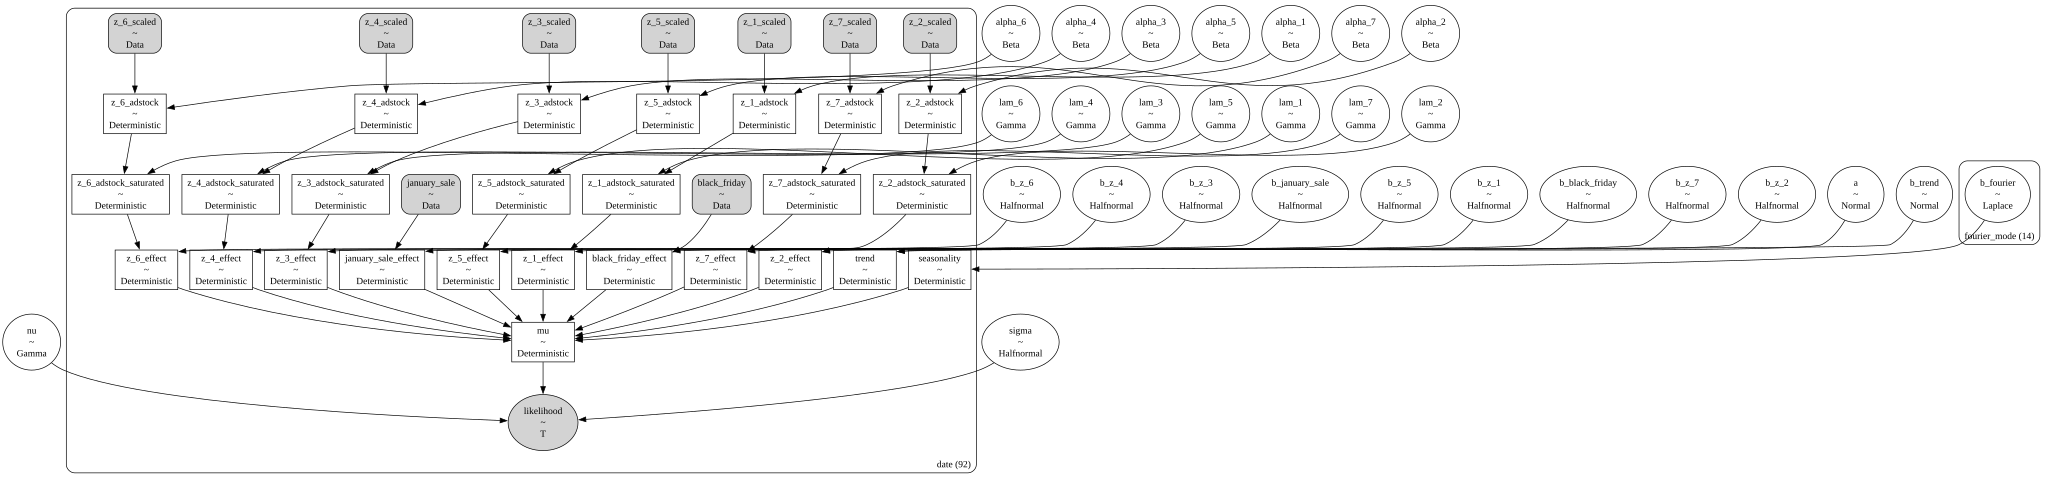

In [21]:
# Setting up priors and entire model

coords = {"date": date, "fourier_mode": np.arange(2 * n_order)}
with pm.Model(coords=coords) as adstock_saturation_model:
    # --- data containers ---
    z_1_scaled_ = pm.Data(name="z_1_scaled", value=z_1_scaled, dims="date")
    z_2_scaled_ = pm.Data(name="z_2_scaled", value=z_2_scaled, dims="date")
    z_3_scaled_ = pm.Data(name="z_3_scaled", value=z_3_scaled, dims="date")
    z_4_scaled_ = pm.Data(name="z_4_scaled", value=z_4_scaled, dims="date")
    z_5_scaled_ = pm.Data(name="z_5_scaled", value=z_5_scaled, dims="date")
    z_6_scaled_ = pm.Data(name="z_6_scaled", value=z_6_scaled, dims="date")
    z_7_scaled_ = pm.Data(name="z_7_scaled", value=z_7_scaled, dims="date")
    black_friday_ = pm.Data(name="black_friday", value=black_friday, dims="date")
    january_sale_ = pm.Data(name="january_sale", value=january_sale, dims="date")
    
    # --- priors ---
    ## intercept
    a = pm.Normal(name="a", mu=0, sigma=0.75)
    ## trend
    b_trend = pm.Normal(name="b_trend", mu=0, sigma=0.35)
    ## seasonality
    b_fourier = pm.Laplace(name="b_fourier", mu=0, b=0.4, dims="fourier_mode")
    ## black friday and january sale
    b_black_friday = pm.HalfNormal(name="b_black_friday", sigma=0.5)
    b_january_sale = pm.HalfNormal(name="b_january_sale", sigma=0.5)
    
    ## channel priors — adstock decay, saturation rate, and coefficient
    alpha_1 = pm.Beta(name="alpha_1", alpha=1, beta=1)
    lam_1   = pm.Gamma(name="lam_1", alpha=1, beta=1)
    b_z_1   = pm.HalfNormal(name="b_z_1", sigma=0.05)   # 

    alpha_2 = pm.Beta(name="alpha_2", alpha=1, beta=1)
    lam_2   = pm.Gamma(name="lam_2", alpha=1, beta=1)
    b_z_2   = pm.HalfNormal(name="b_z_2", sigma=0.007)  # 

    alpha_3 = pm.Beta(name="alpha_3", alpha=1, beta=1)
    lam_3   = pm.Gamma(name="lam_3", alpha=1, beta=1)
    b_z_3   = pm.HalfNormal(name="b_z_3", sigma=0.05)   # 

    alpha_4 = pm.Beta(name="alpha_4", alpha=1, beta=1)
    lam_4   = pm.Gamma(name="lam_4", alpha=1, beta=1)
    b_z_4   = pm.HalfNormal(name="b_z_4", sigma=0.05)   # 

    alpha_5 = pm.Beta(name="alpha_5", alpha=1, beta=1)
    lam_5   = pm.Gamma(name="lam_5", alpha=1, beta=1)
    b_z_5   = pm.HalfNormal(name="b_z_5", sigma=0.08)   # 

    alpha_6 = pm.Beta(name="alpha_6", alpha=1, beta=1)
    lam_6   = pm.Gamma(name="lam_6", alpha=1, beta=1)
    b_z_6   = pm.HalfNormal(name="b_z_6", sigma=0.25)   # 

    alpha_7 = pm.Beta(name="alpha_7", alpha=1, beta=1)
    lam_7   = pm.Gamma(name="lam_7", alpha=1, beta=1)
    b_z_7   = pm.HalfNormal(name="b_z_7", sigma=0.05)   # 

    ## noise and degrees of freedom
    sigma = pm.HalfNormal(name="sigma", sigma=0.05)
    nu    = pm.Gamma(name="nu", alpha=25, beta=2)

    # --- model parametrization ---
    trend = pm.Deterministic("trend", a + b_trend * t, dims="date")
    seasonality = pm.Deterministic(
        name="seasonality", var=pm.math.dot(fourier_features, b_fourier), dims="date"
    )
    black_friday_effect = pm.Deterministic(
        name="black_friday_effect", var=b_black_friday * black_friday_, dims="date"
    )
    january_sale_effect = pm.Deterministic(
        name="january_sale_effect", var=b_january_sale * january_sale_, dims="date"
    )    

    # z_1 pipeline: adstock -> saturation -> scaled contribution
    z_1_adstock = pm.Deterministic(
        name="z_1_adstock",
        var=geometric_adstock(x=z_1_scaled_, alpha=alpha_1, l_max=12), dims="date",
    )
    z_1_adstock_saturated = pm.Deterministic(
        name="z_1_adstock_saturated",
        var=logistic_saturation(x=z_1_adstock, lam=lam_1), dims="date",
    )
    z_1_effect = pm.Deterministic(
        name="z_1_effect", var=b_z_1 * z_1_adstock_saturated, dims="date"
    )

    # z_2 pipeline: adstock -> saturation -> scaled contribution
    z_2_adstock = pm.Deterministic(
        name="z_2_adstock",
        var=geometric_adstock(x=z_2_scaled_, alpha=alpha_2, l_max=12), dims="date",
    )
    z_2_adstock_saturated = pm.Deterministic(
        name="z_2_adstock_saturated",
        var=logistic_saturation(x=z_2_adstock, lam=lam_2), dims="date",
    )
    z_2_effect = pm.Deterministic(
        name="z_2_effect", var=b_z_2 * z_2_adstock_saturated, dims="date"
    )

    # z_3 pipeline: adstock -> saturation -> scaled contribution
    z_3_adstock = pm.Deterministic(
        name="z_3_adstock",
        var=geometric_adstock(x=z_3_scaled_, alpha=alpha_3, l_max=12), dims="date",
    )
    z_3_adstock_saturated = pm.Deterministic(
        name="z_3_adstock_saturated",
        var=logistic_saturation(x=z_3_adstock, lam=lam_3), dims="date",
    )
    z_3_effect = pm.Deterministic(
        name="z_3_effect", var=b_z_3 * z_3_adstock_saturated, dims="date"
    )

    # z_4 pipeline: adstock -> saturation -> scaled contribution
    z_4_adstock = pm.Deterministic(
        name="z_4_adstock",
        var=geometric_adstock(x=z_4_scaled_, alpha=alpha_4, l_max=12), dims="date",
    )
    z_4_adstock_saturated = pm.Deterministic(
        name="z_4_adstock_saturated",
        var=logistic_saturation(x=z_4_adstock, lam=lam_4), dims="date",
    )
    z_4_effect = pm.Deterministic(
        name="z_4_effect", var=b_z_4 * z_4_adstock_saturated, dims="date"
    )

    # z_5 pipeline: adstock -> saturation -> scaled contribution
    z_5_adstock = pm.Deterministic(
        name="z_5_adstock",
        var=geometric_adstock(x=z_5_scaled_, alpha=alpha_5, l_max=12), dims="date",
    )
    z_5_adstock_saturated = pm.Deterministic(
        name="z_5_adstock_saturated",
        var=logistic_saturation(x=z_5_adstock, lam=lam_5), dims="date",
    )
    z_5_effect = pm.Deterministic(
        name="z_5_effect", var=b_z_5 * z_5_adstock_saturated, dims="date"
    )

    # z_6 pipeline: adstock -> saturation -> scaled contribution
    z_6_adstock = pm.Deterministic(
        name="z_6_adstock",
        var=geometric_adstock(x=z_6_scaled_, alpha=alpha_6, l_max=12), dims="date",
    )
    z_6_adstock_saturated = pm.Deterministic(
        name="z_6_adstock_saturated",
        var=logistic_saturation(x=z_6_adstock, lam=lam_6), dims="date",
    )
    z_6_effect = pm.Deterministic(
        name="z_6_effect", var=b_z_6 * z_6_adstock_saturated, dims="date"
    )

    # z_7 pipeline: adstock -> saturation -> scaled contribution
    z_7_adstock = pm.Deterministic(
        name="z_7_adstock",
        var=geometric_adstock(x=z_7_scaled_, alpha=alpha_7, l_max=12), dims="date",
    )
    z_7_adstock_saturated = pm.Deterministic(
        name="z_7_adstock_saturated",
        var=logistic_saturation(x=z_7_adstock, lam=lam_7), dims="date",
    )
    z_7_effect = pm.Deterministic(
        name="z_7_effect", var=b_z_7 * z_7_adstock_saturated, dims="date"
    )

    # mu combines all effects
    mu = pm.Deterministic(
        name="mu",
        var=trend + seasonality + black_friday_effect + january_sale_effect
            + z_1_effect + z_2_effect + z_3_effect + z_4_effect
            + z_5_effect + z_6_effect + z_7_effect,
        dims="date",
    )

    # --- likelihood ---
    pm.StudentT(name="likelihood", nu=nu, mu=mu, sigma=sigma, observed=y_scaled, dims="date")

    # --- prior predictive samples ---
    adstock_saturation_model_prior_predictive = pm.sample_prior_predictive()

pm.model_to_graphviz(model=adstock_saturation_model)

In [ ]:
# useful way to see the priors we have chosen
palette = "viridis_r"
cmap = plt.get_cmap(palette)
percs = np.linspace(51, 99, 100)
colors = (percs - np.min(percs)) / (np.max(percs) - np.min(percs))

fig, ax = plt.subplots()

for i, p in enumerate(percs[::-1]):
    upper = np.percentile(
        adstock_saturation_model_prior_predictive.prior_predictive["likelihood"],
        p,
        axis=1,
    )
    lower = np.percentile(
        adstock_saturation_model_prior_predictive.prior_predictive["likelihood"], 100 - p, axis=1
    )
    color_val = colors[i]
    ax.fill_between(
        x=date,
        y1=upper.flatten(),
        y2=lower.flatten(),
        color=cmap(color_val),
        alpha=0.1,
    )

sns.lineplot(x=date, y=y_scaled, color="black", label="revenue (scaled)", ax=ax)
ax.legend()
ax.set(title="Adstock Saturation Model - Prior Predictive");
plt.savefig("prior_predictive.png", dpi=150, bbox_inches="tight")
plt.show()

#### Comment: 
- Visualizing the prior predictive distribution of the model helps alot! — essentially asking "what range of outcomes does our model consider plausible before seeing any data?"
- The overall purpose is a prior predictive check — a sanity check to verify that the priors are neither too tight (model has already made up its mind) nor too diffuse (model considers wildly unrealistic values). Ideally scaled revenue should sit comfortably within the bulk of the shaded region, but the bands should still be wide enough to reflect genuine prior uncertainty.

## 3. Model Training

In [23]:
with adstock_saturation_model:
    adstock_saturation_model_trace = pm.sample(
        nuts_sampler="numpyro",
        draws=8_000,
        chains=4,
        tune=2_000,           # add more tuning steps (default is 1000)
        target_accept=0.95,    # increase from default 0.8 to reduce divergences
        idata_kwargs={"log_likelihood": True},
    )
    adstock_saturation_model_posterior_predictive = pm.sample_posterior_predictive(
        trace=adstock_saturation_model_trace,
    )

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

Sampling: [likelihood]


Output()

## 4. Results

In [24]:
az.summary(
    data=adstock_saturation_model_trace,
    var_names=[
        "a", "b_trend",
        "b_z_1", "b_z_2", "b_z_3", "b_z_4", "b_z_5", "b_z_6", "b_z_7",
        "alpha_1", "alpha_3", "alpha_4", "alpha_5", "alpha_6", "alpha_7",
        "lam_1", "lam_3", "lam_4", "lam_5", "lam_6", "lam_7",
        "sigma", "nu",
    ]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.195,0.045,0.109,0.274,0.000,0.000,14302.0,16737.0,1.0
b_trend,0.017,0.047,-0.070,0.107,0.000,0.000,13939.0,16665.0,1.0
b_z_1,0.034,0.027,0.000,0.082,0.000,0.000,25712.0,14850.0,1.0
b_z_2,0.006,0.004,0.000,0.013,0.000,0.000,25885.0,13979.0,1.0
b_z_3,0.046,0.033,0.000,0.105,0.000,0.000,21582.0,12965.0,1.0
b_z_4,0.035,0.028,0.000,0.086,0.000,0.000,25017.0,14862.0,1.0
b_z_5,0.070,0.050,0.000,0.160,0.000,0.000,18436.0,14029.0,1.0
b_z_6,0.239,0.132,0.012,0.479,0.001,0.001,20777.0,11166.0,1.0
b_z_7,0.073,0.043,0.000,0.145,0.000,0.000,14732.0,12281.0,1.0
alpha_1,0.456,0.282,0.000,0.918,0.001,0.001,39296.0,20672.0,1.0


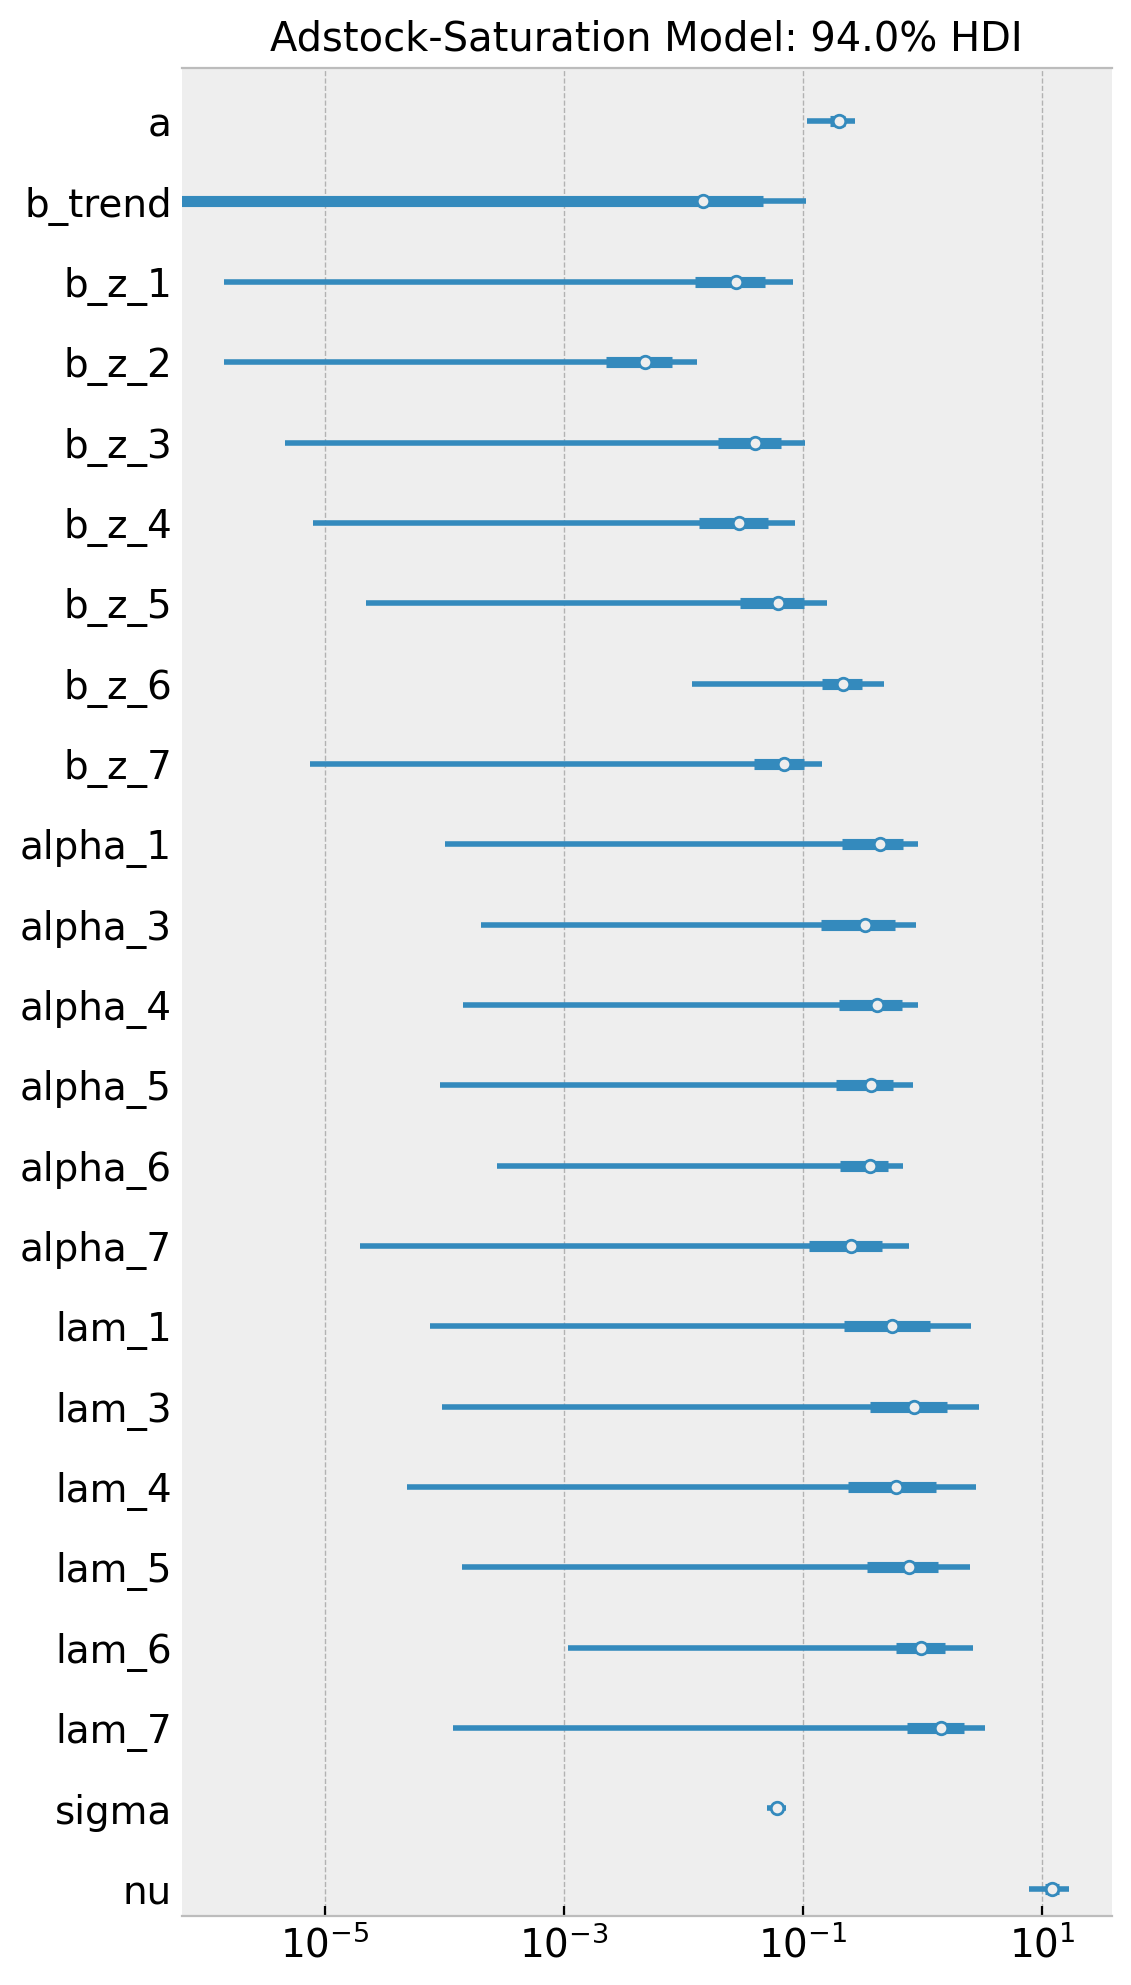

In [25]:
fig, ax = plt.subplots(figsize=(6, 12))
az.plot_forest(
    data=adstock_saturation_model_trace,
    var_names=[
        "a", "b_trend",
        "b_z_1","b_z_2" ,"b_z_3", "b_z_4", "b_z_5", "b_z_6", "b_z_7",
        "alpha_1", "alpha_3", "alpha_4", "alpha_5", "alpha_6", "alpha_7",
        "lam_1", "lam_3", "lam_4", "lam_5", "lam_6", "lam_7",
        "sigma", "nu",
    ],
    combined=True,
    ax=ax,
)
ax.set(
    title="Adstock-Saturation Model: 94.0% HDI",
    xscale="log"
)
plt.show()

In [26]:
pp = az.extract(
    data=adstock_saturation_model_posterior_predictive,
    group="posterior_predictive",
    var_names="likelihood",
)
print("inf count:", np.isinf(pp.values).sum())
print("nan count:", np.isnan(pp.values).sum())
print("max abs value:", np.abs(pp.values[np.isfinite(pp.values)]).max())

inf count: 0
nan count: 0
max abs value: 1.4340389616684326


In [27]:
divergences = adstock_saturation_model_trace.sample_stats["diverging"].values.sum()
print(f"Total divergences: {divergences}")

Total divergences: 0


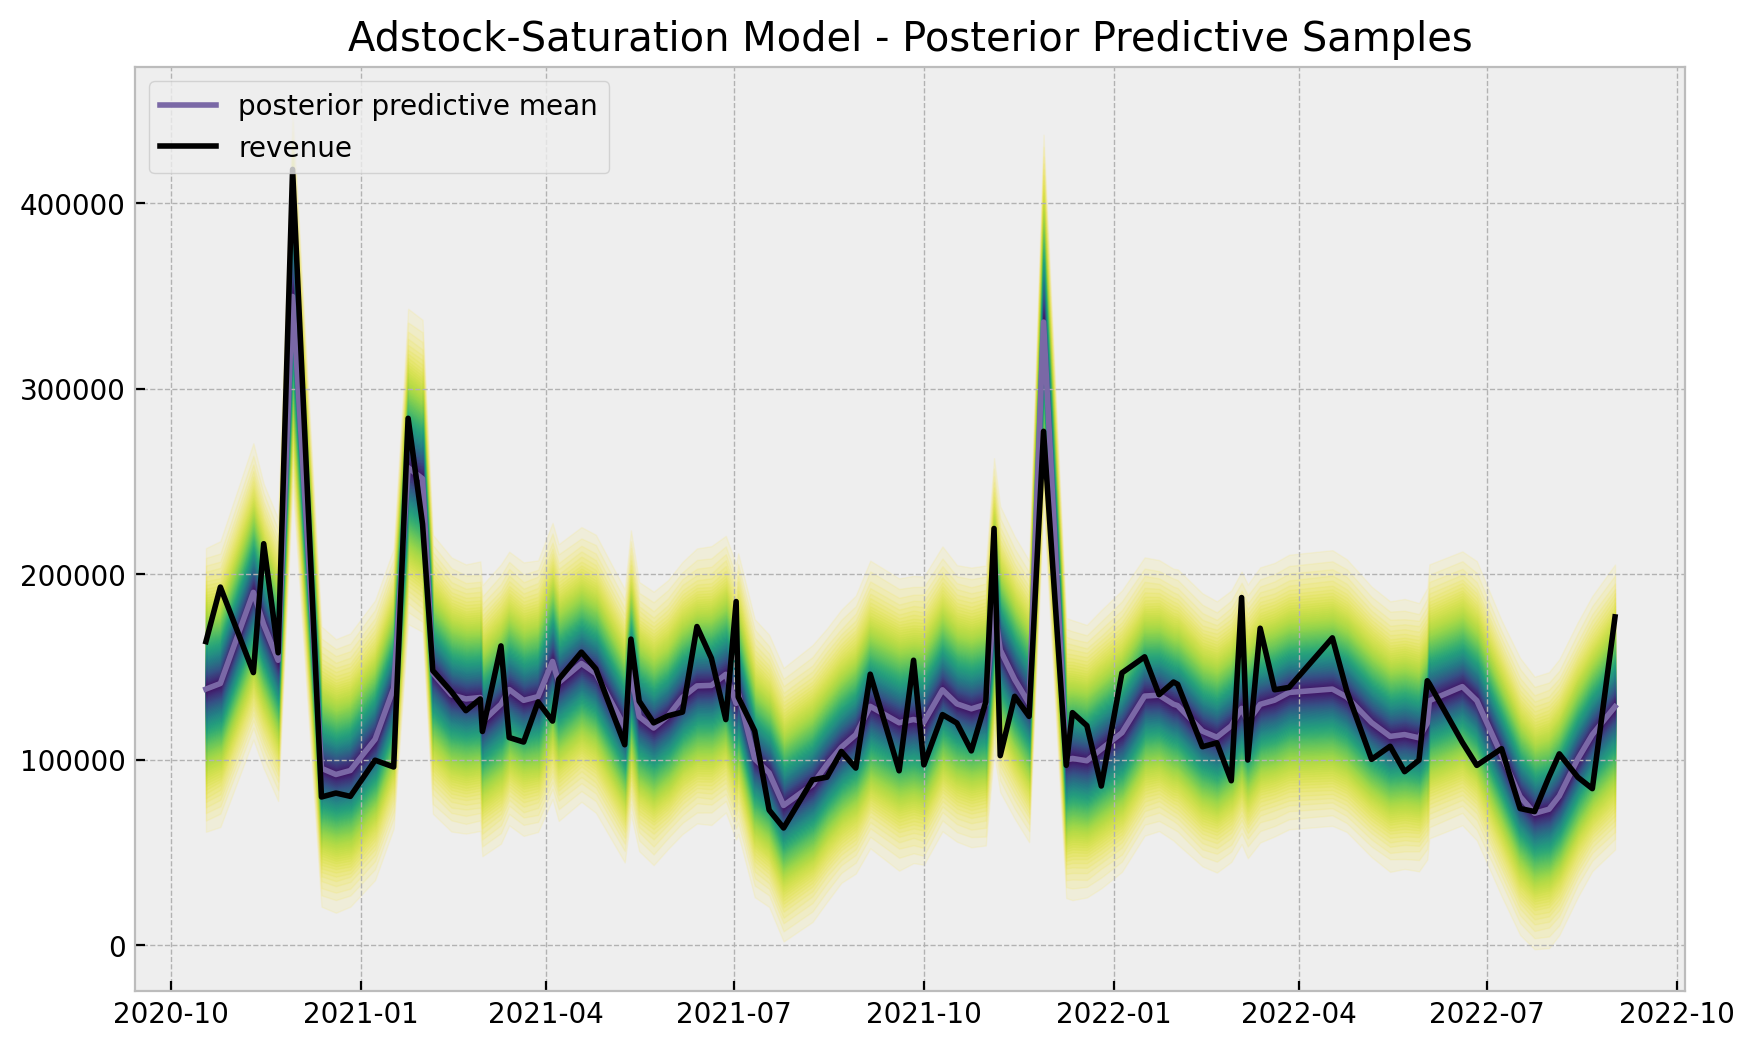

In [28]:
posterior_predictive_likelihood = az.extract(
    data=adstock_saturation_model_posterior_predictive,
    group="posterior_predictive",
    var_names="likelihood",
)

posterior_predictive_likelihood_inv = endog_scaler.inverse_transform(
    X=posterior_predictive_likelihood
)

fig, ax = plt.subplots()

for i, p in enumerate(percs[::-1]):
    upper = np.percentile(posterior_predictive_likelihood_inv, p, axis=1)
    lower = np.percentile(posterior_predictive_likelihood_inv, 100 - p, axis=1)
    color_val = colors[i]
    ax.fill_between(
        x=date,
        y1=upper,
        y2=lower,
        color=cmap(color_val),
        alpha=0.1,
    )

sns.lineplot(
    x=date,
    y=posterior_predictive_likelihood_inv.mean(axis=1),
    color="C2",
    label="posterior predictive mean",
    ax=ax,
)
sns.lineplot(
    x=date,
    y=y,
    color="black",
    label="revenue",
    ax=ax,
)
ax.legend(loc="upper left")
ax.set(title="Adstock-Saturation Model - Posterior Predictive Samples");
plt.savefig("posterior_predictive.png", dpi=150, bbox_inches="tight");
plt.show()

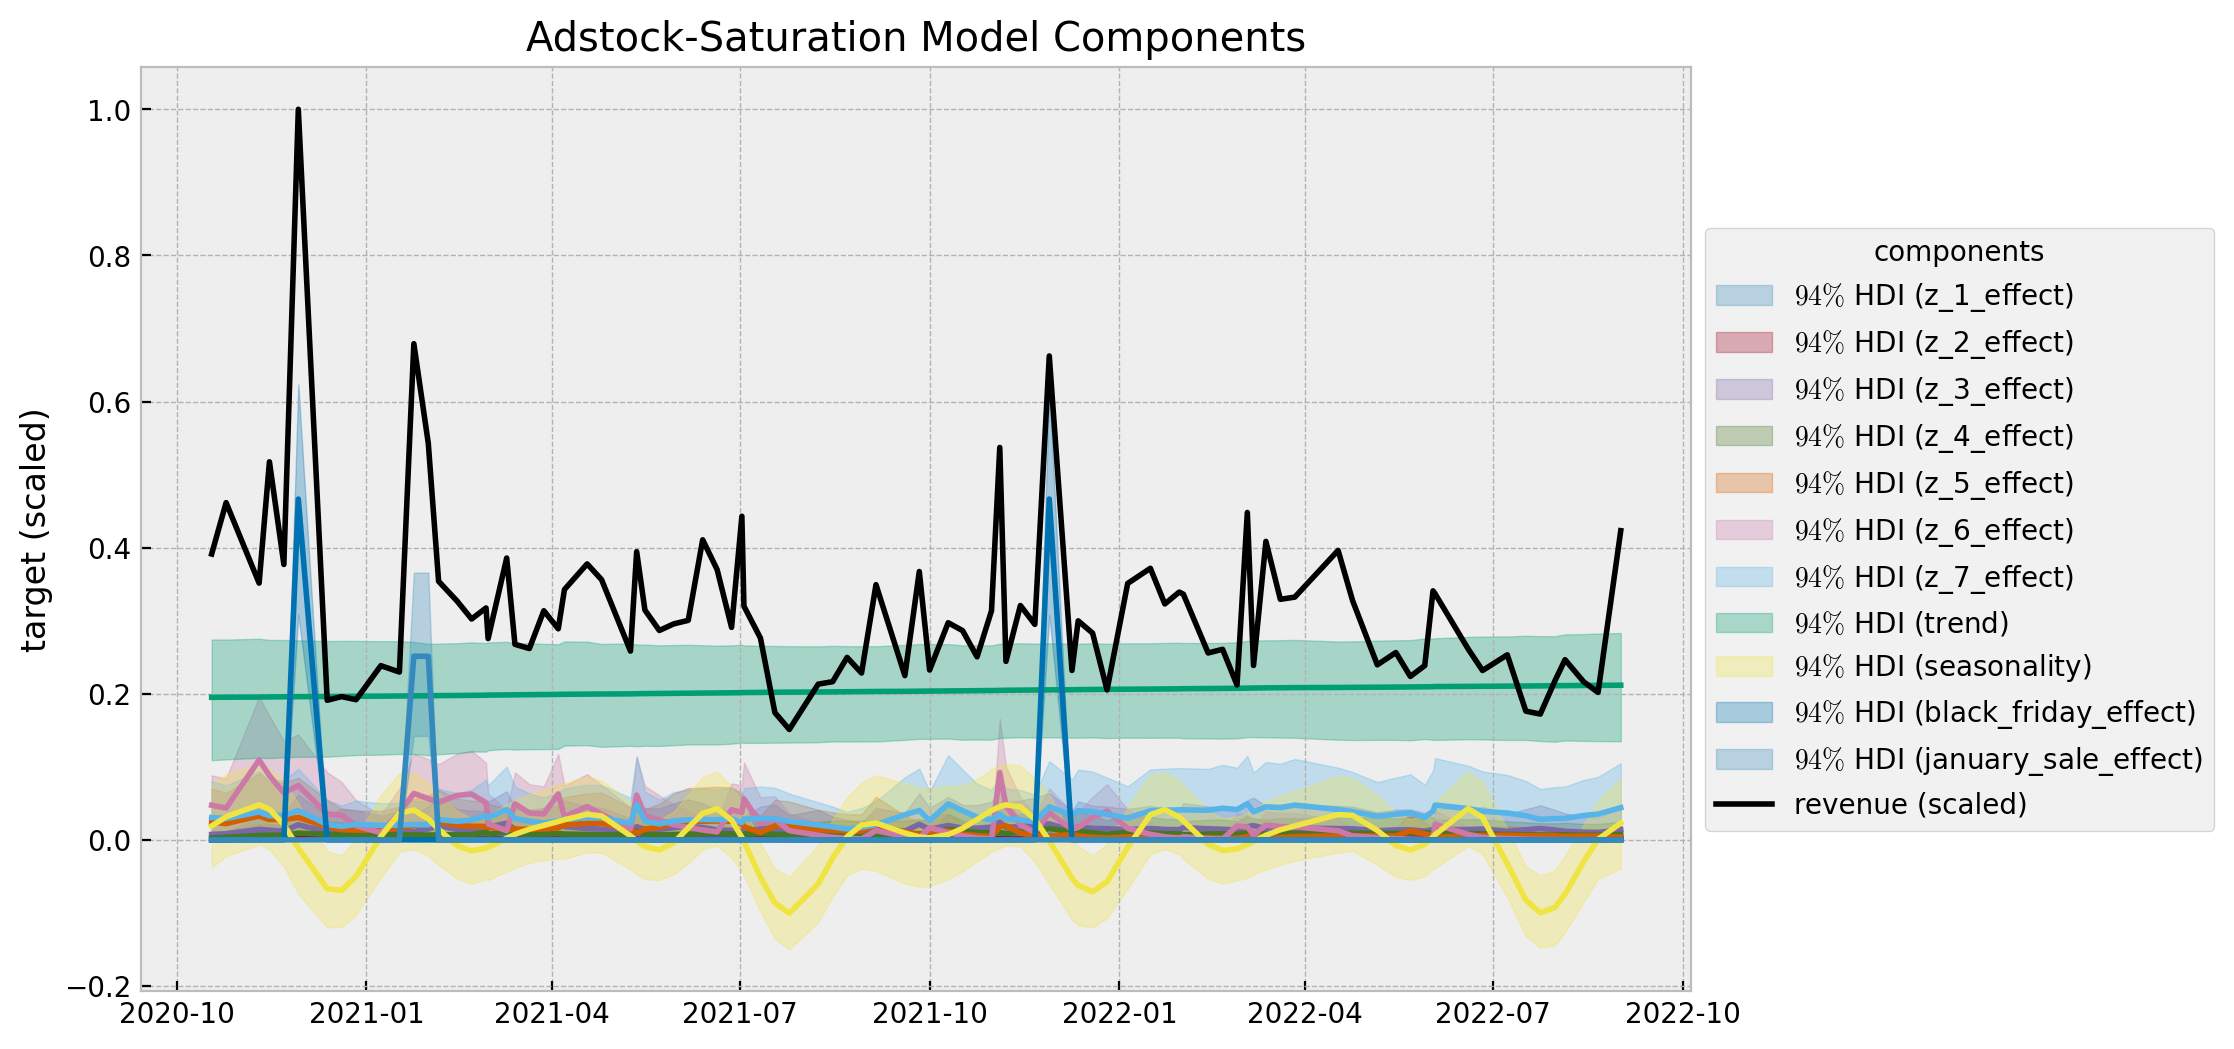

In [29]:
# compute HDI for all the model parameters
model_hdi = az.hdi(ary=adstock_saturation_model_trace)

fig, ax = plt.subplots()

for i, var_effect in enumerate([
    "z_1_effect","z_2_effect", "z_3_effect", "z_4_effect",
    "z_5_effect", "z_6_effect", "z_7_effect",
    "trend", "seasonality", "black_friday_effect", "january_sale_effect"
]):
    ax.fill_between(
        x=date,
        y1=model_hdi[var_effect][:, 0],
        y2=model_hdi[var_effect][:, 1],
        color=f"C{i}",
        alpha=0.3,
        label=f"$94\%$ HDI ({var_effect})",
    )
    sns.lineplot(
        x=date,
        y=adstock_saturation_model_trace.posterior[var_effect]
        .stack(sample=("chain", "draw"))
        .mean(axis=1),
        color=f"C{i}",
    )

sns.lineplot(x=date, y=y_scaled, color="black", alpha=1.0, label="revenue (scaled)", ax=ax)
ax.legend(title="components", loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(title="Adstock-Saturation Model Components", ylabel="target (scaled)");
plt.show()

#### Comment: 
- Each colored band shows how much each component contributes to the scaled revenue at each point in time. The black line is the actual revenue, and ideally the sum of all colored components should trace it closely. One can tell that our seasonality elements has captured the periodic behaviors of the revenue (target) data. Also the trend element of the modeling has grasped the gradual change. Moreover, the beneficial effect of injecting the knowledge about Black-Fiday in the model development is quite stark in helping to have a more fitting model. 

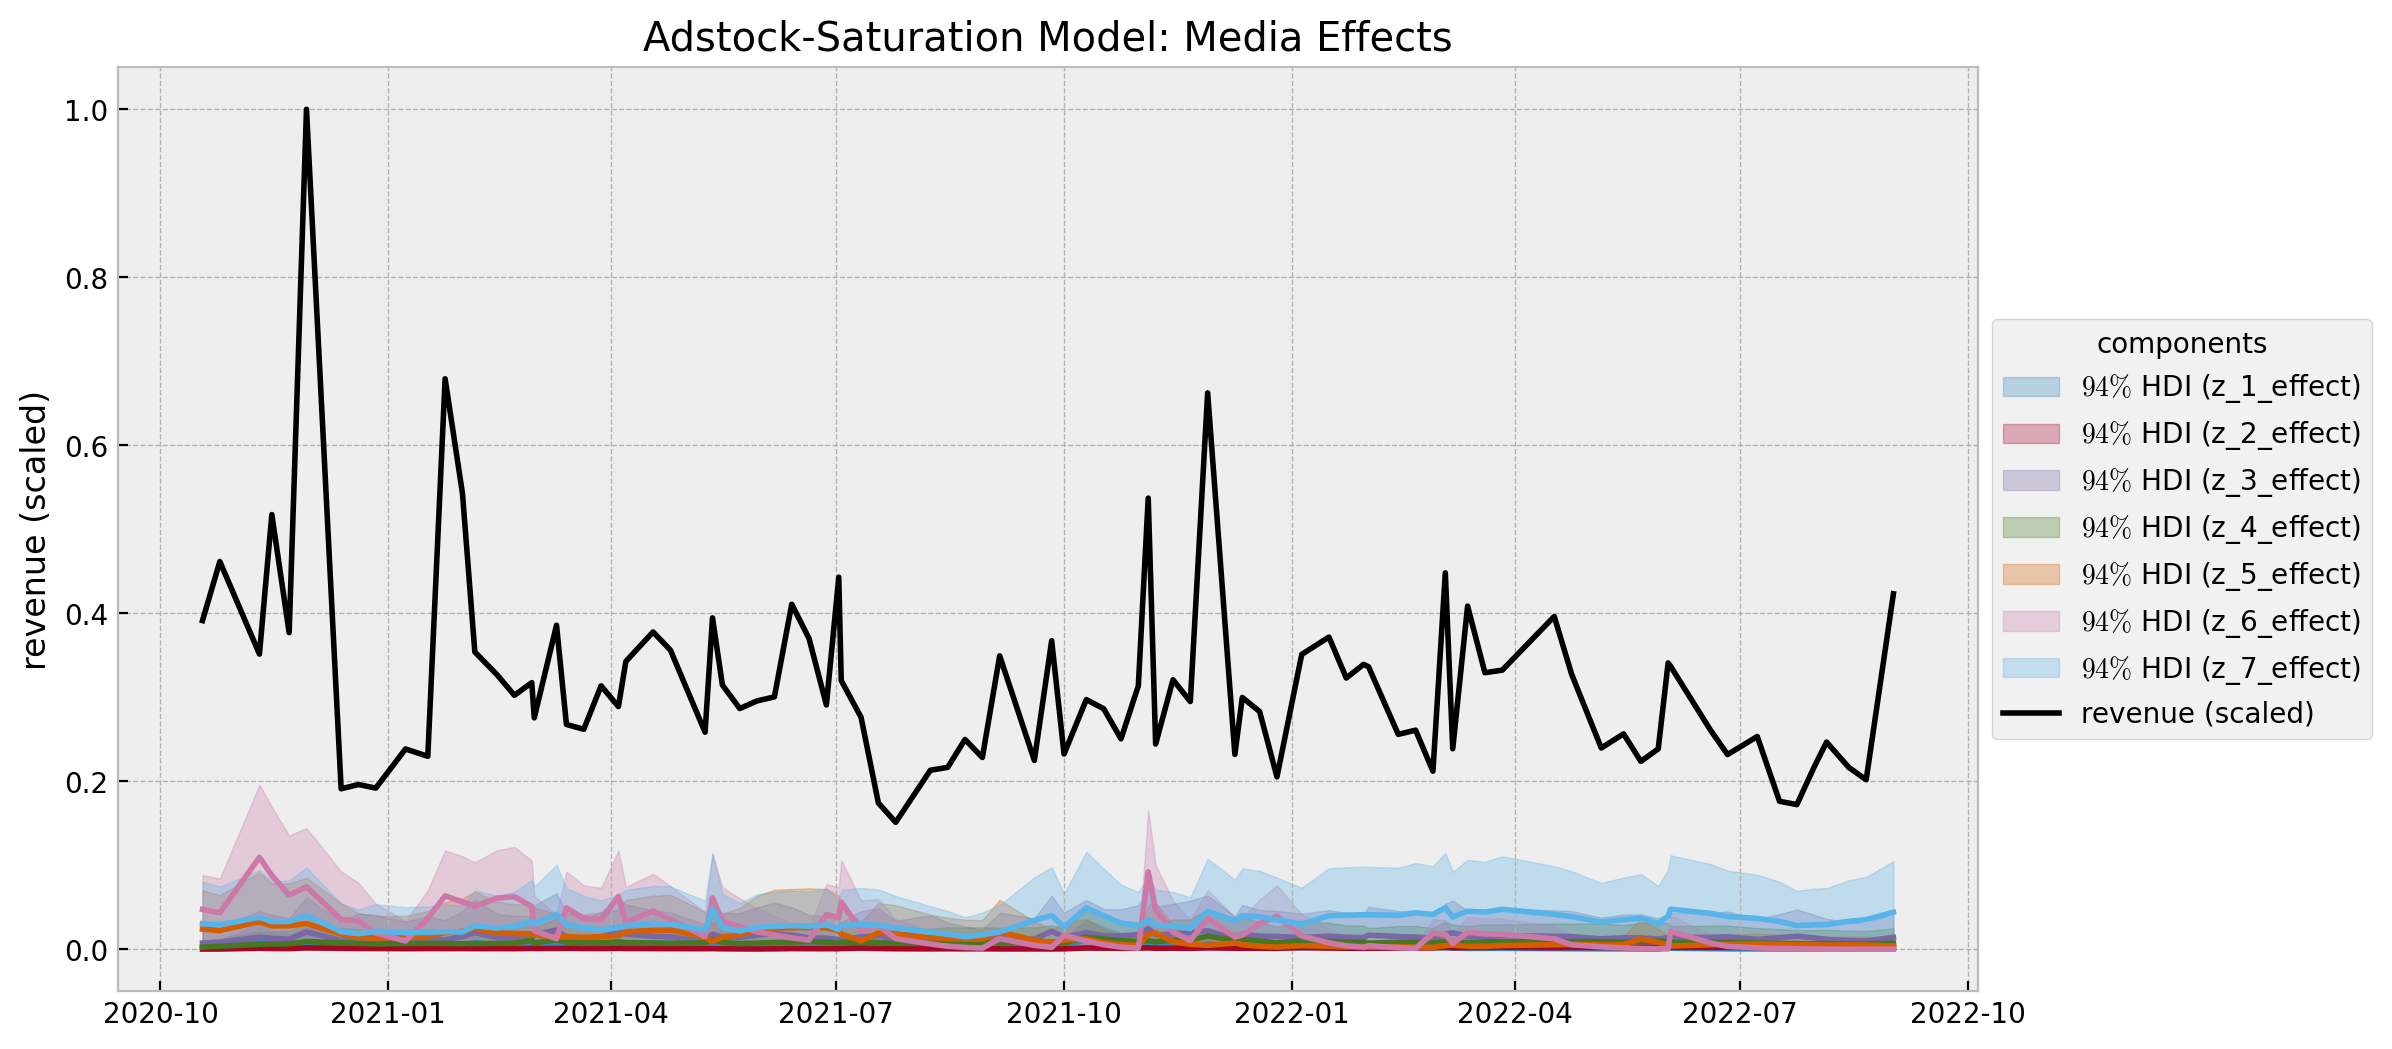

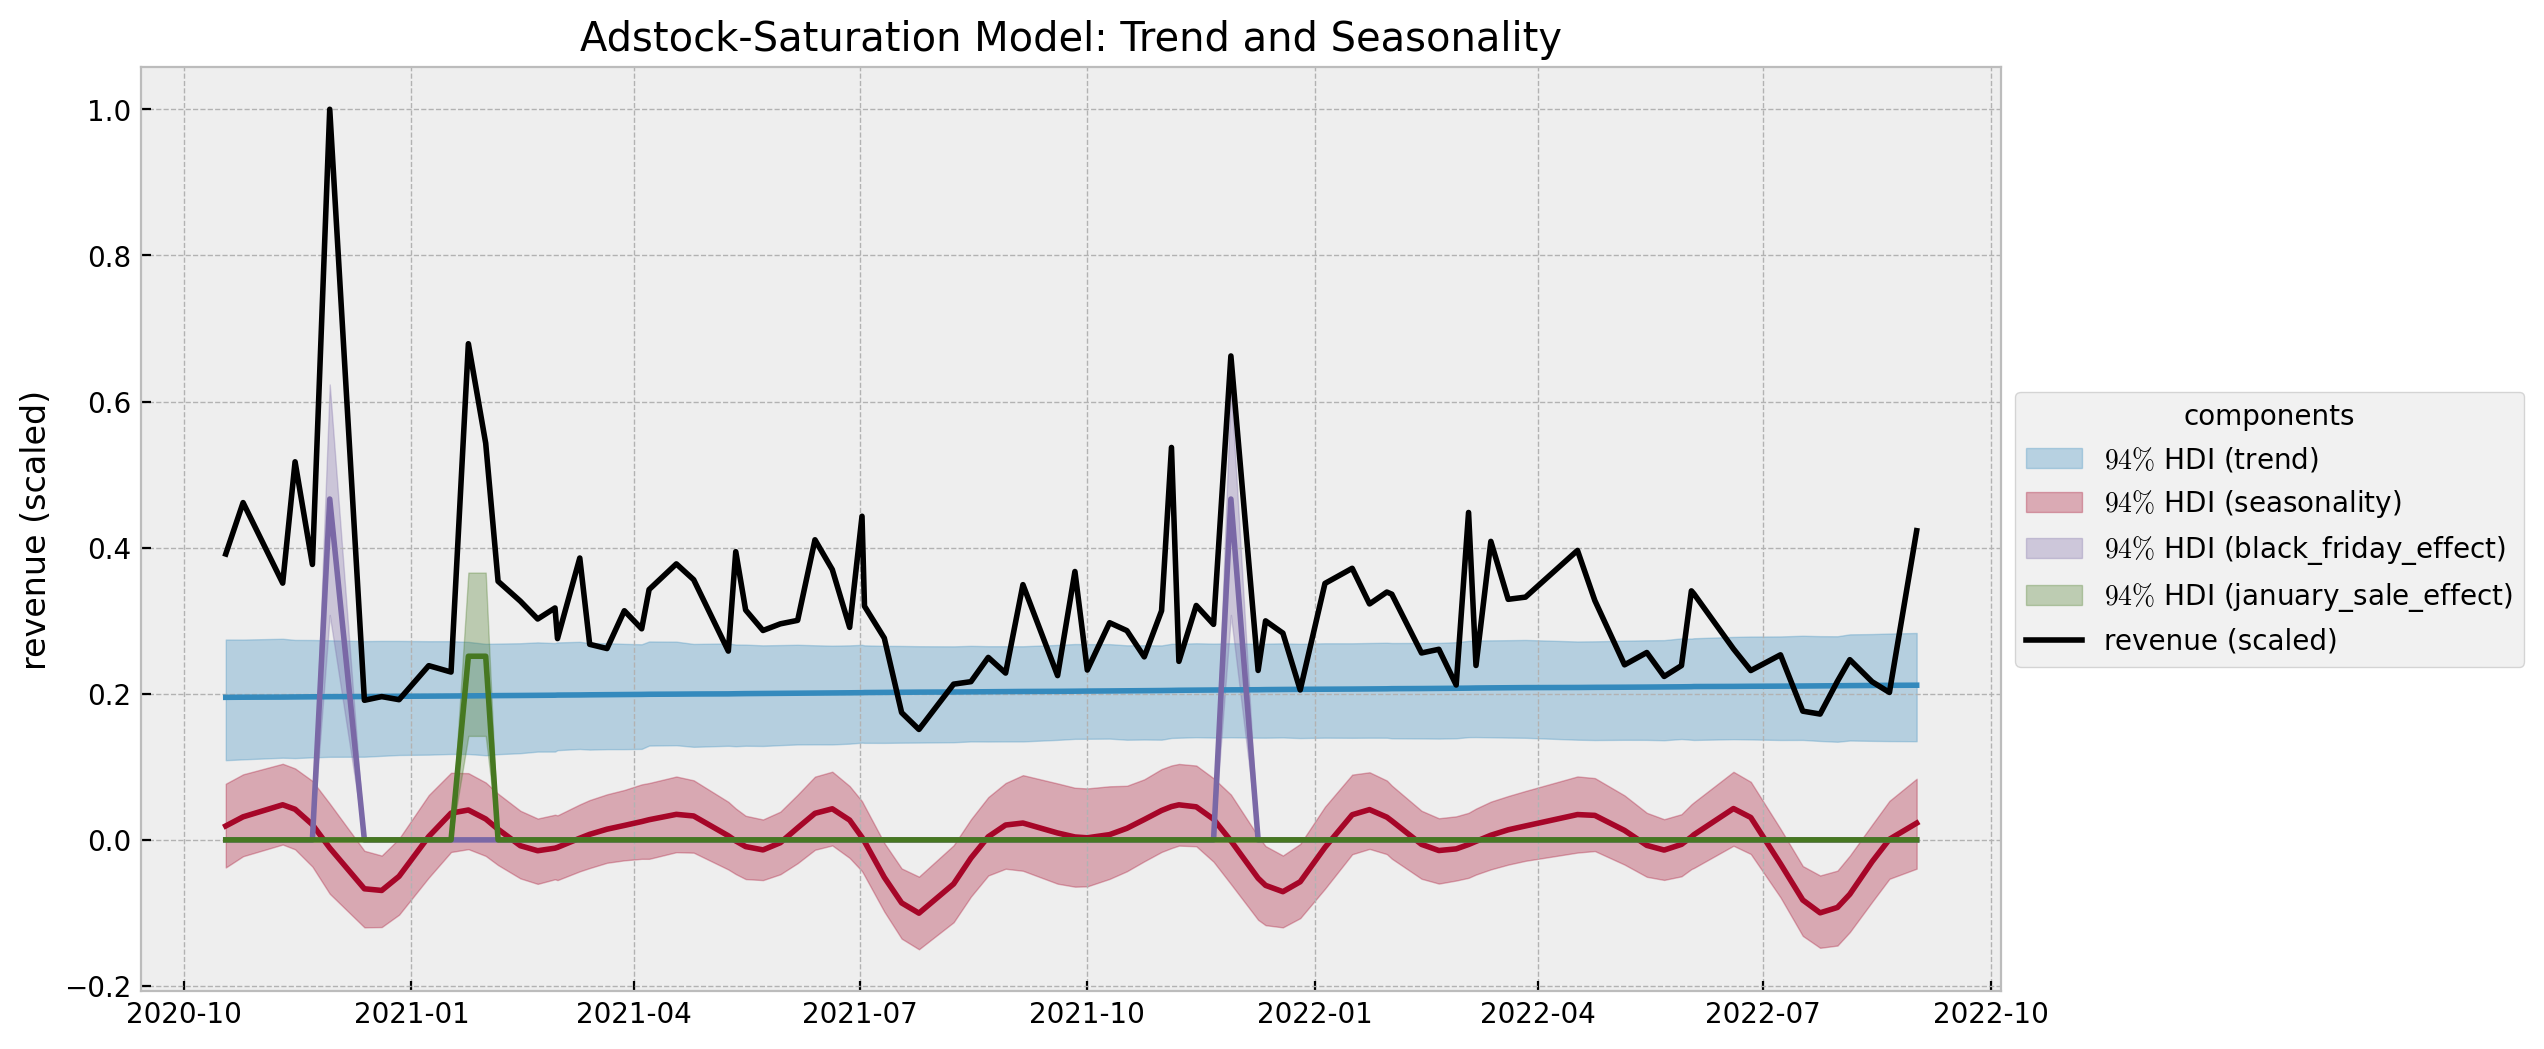

In [38]:
# compute HDI for all the model parameters
model_hdi = az.hdi(ary=adstock_saturation_model_trace)

media_vars = [
    "z_1_effect", "z_2_effect","z_3_effect", "z_4_effect",
    "z_5_effect", "z_6_effect", "z_7_effect"
]

base_vars = ["trend", "seasonality","black_friday_effect","january_sale_effect"]

# ---- Plot 1: target + media effects ----
fig, ax = plt.subplots(figsize=(12, 6))

for i, var_effect in enumerate(media_vars):
    ax.fill_between(
        x=date,
        y1=model_hdi[var_effect][:, 0],
        y2=model_hdi[var_effect][:, 1],
        color=f"C{i}",
        alpha=0.3,
        label=f"$94\%$ HDI ({var_effect})",
    )
    sns.lineplot(
        x=date,
        y=adstock_saturation_model_trace.posterior[var_effect]
        .stack(sample=("chain", "draw"))
        .mean(axis=1),
        color=f"C{i}",
        ax=ax,
    )

sns.lineplot(
    x=date, y=y_scaled, color="black", alpha=1.0, label="revenue (scaled)", ax=ax
)
ax.legend(title="components", loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(title="Adstock-Saturation Model: Media Effects", ylabel="revenue (scaled)")
plt.savefig("media_contributions.png", dpi=150, bbox_inches="tight")

# ---- Plot 2: target + trend/seasonality ----
fig, ax = plt.subplots(figsize=(12, 6))

for i, var_effect in enumerate(base_vars):
    ax.fill_between(
        x=date,
        y1=model_hdi[var_effect][:, 0],
        y2=model_hdi[var_effect][:, 1],
        color=f"C{i}",
        alpha=0.3,
        label=f"$94\%$ HDI ({var_effect})",
    )
    sns.lineplot(
        x=date,
        y=adstock_saturation_model_trace.posterior[var_effect]
        .stack(sample=("chain", "draw"))
        .mean(axis=1),
        color=f"C{i}",
        ax=ax,
    )

sns.lineplot(
    x=date, y=y_scaled, color="black", alpha=1.0, label="revenue (scaled)", ax=ax
)
ax.legend(title="components", loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(title="Adstock-Saturation Model: Trend and Seasonality", ylabel="revenue (scaled)");
plt.savefig("component_contributions.png", dpi=150, bbox_inches="tight")
plt.show()

# ROAS and ROI computations

- ROAS = incremental_revenue / spend — how much revenue per 1\$ spent
- ROI = (incremental_revenue - spend) / spend — how much profit per 1\$ spent, so a ROI of 1.0 means you doubled your money

In [31]:
# For ROAS we need one counterfactual run per channel:
# zero out that channel's spend while keeping all others at their observed values.

roas_traces = {}

for channel in ["z_1","z_2", "z_3", "z_4", "z_5", "z_6", "z_7"]:
    trace_copy = adstock_saturation_model_trace.copy()

    new_data = {
        "z_1_scaled": z_1_scaled,
        "z_2_scaled": z_2_scaled,
        "z_3_scaled": z_3_scaled,
        "z_4_scaled": z_4_scaled,
        "z_5_scaled": z_5_scaled,
        "z_6_scaled": z_6_scaled,
        "z_7_scaled": z_7_scaled,
    }
    # Zero out only the current channel
    new_data[f"{channel}_scaled"] = np.zeros(n_obs)

    with adstock_saturation_model:
        pm.set_data(new_data=new_data)
        trace_copy.extend(
            other=pm.sample_posterior_predictive(
                trace=trace_copy, var_names=["likelihood"]
            )
        )

    roas_traces[channel] = trace_copy

Sampling: [likelihood]


Output()

Sampling: [likelihood]


Output()

Sampling: [likelihood]


...

Output()

Sampling: [likelihood]


Output()

Sampling: [likelihood]


Output()

In [32]:
# Extract base posterior predictive (all channels active) once
pp_base = endog_scaler.inverse_transform(
    X=az.extract(
        data=adstock_saturation_model_posterior_predictive,
        group="posterior_predictive",
        var_names=["likelihood"],
    )
)

roas = {}

for channel, z_obs in zip(
    ["z_1", "z_2", "z_3", "z_4", "z_5", "z_6", "z_7"],
    [z_1, z_2,z_3, z_4, z_5, z_6, z_7],
):
    pp_counterfactual = endog_scaler.inverse_transform(
        X=az.extract(
            data=roas_traces[channel],
            group="posterior_predictive",
            var_names=["likelihood"],
        )
    )

    roas_numerator = (pp_base - pp_counterfactual).sum(axis=0)
    roas[channel] = roas_numerator / z_obs.sum()

In [ ]:
fig, axes = plt.subplots(7, 1, figsize=(10, 28))

for i, channel in enumerate(["z_1","z_2", "z_3", "z_4", "z_5", "z_6", "z_7"]):
    roas_samples = roas[channel]
    roas_mean = roas_samples.mean()
    roas_hdi  = az.hdi(ary=roas_samples)

    ax = axes[i]
    sns.histplot(x=roas_samples, kde=True, ax=ax)
    ax.axvline(
        x=roas_mean,
        color="C0", linestyle="--",
        label=f"mean = {roas_mean: 0.3f}",
    )
    ax.axvline(
        x=roas_hdi[0],
        color="C1", linestyle="--",
        label=f"HDI_lwr = {roas_hdi[0]: 0.3f}",
    )
    ax.axvline(
        x=roas_hdi[1],
        color="C2", linestyle="--",
        label=f"HDI_upr = {roas_hdi[1]: 0.3f}",
    )
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    ax.set(title=f"Adstock Saturation Model ROAS — {channel}")

fig.suptitle("ROAS by Channel", y=1.01)
plt.tight_layout();
plt.savefig("ROAS.png", dpi=150, bbox_inches="tight");
plt.show()

### ROI 

In [34]:
# Channel costs (total spend over the period)
costs = {
    "z_1": z_1.sum(),
    "z_2": z_2.sum(),
    "z_3": z_3.sum(),
    "z_4": z_4.sum(),
    "z_5": z_5.sum(),
    "z_6": z_6.sum(),
    "z_7": z_7.sum(),
}

roi = {channel: roas[channel] - 1 for channel in roas}

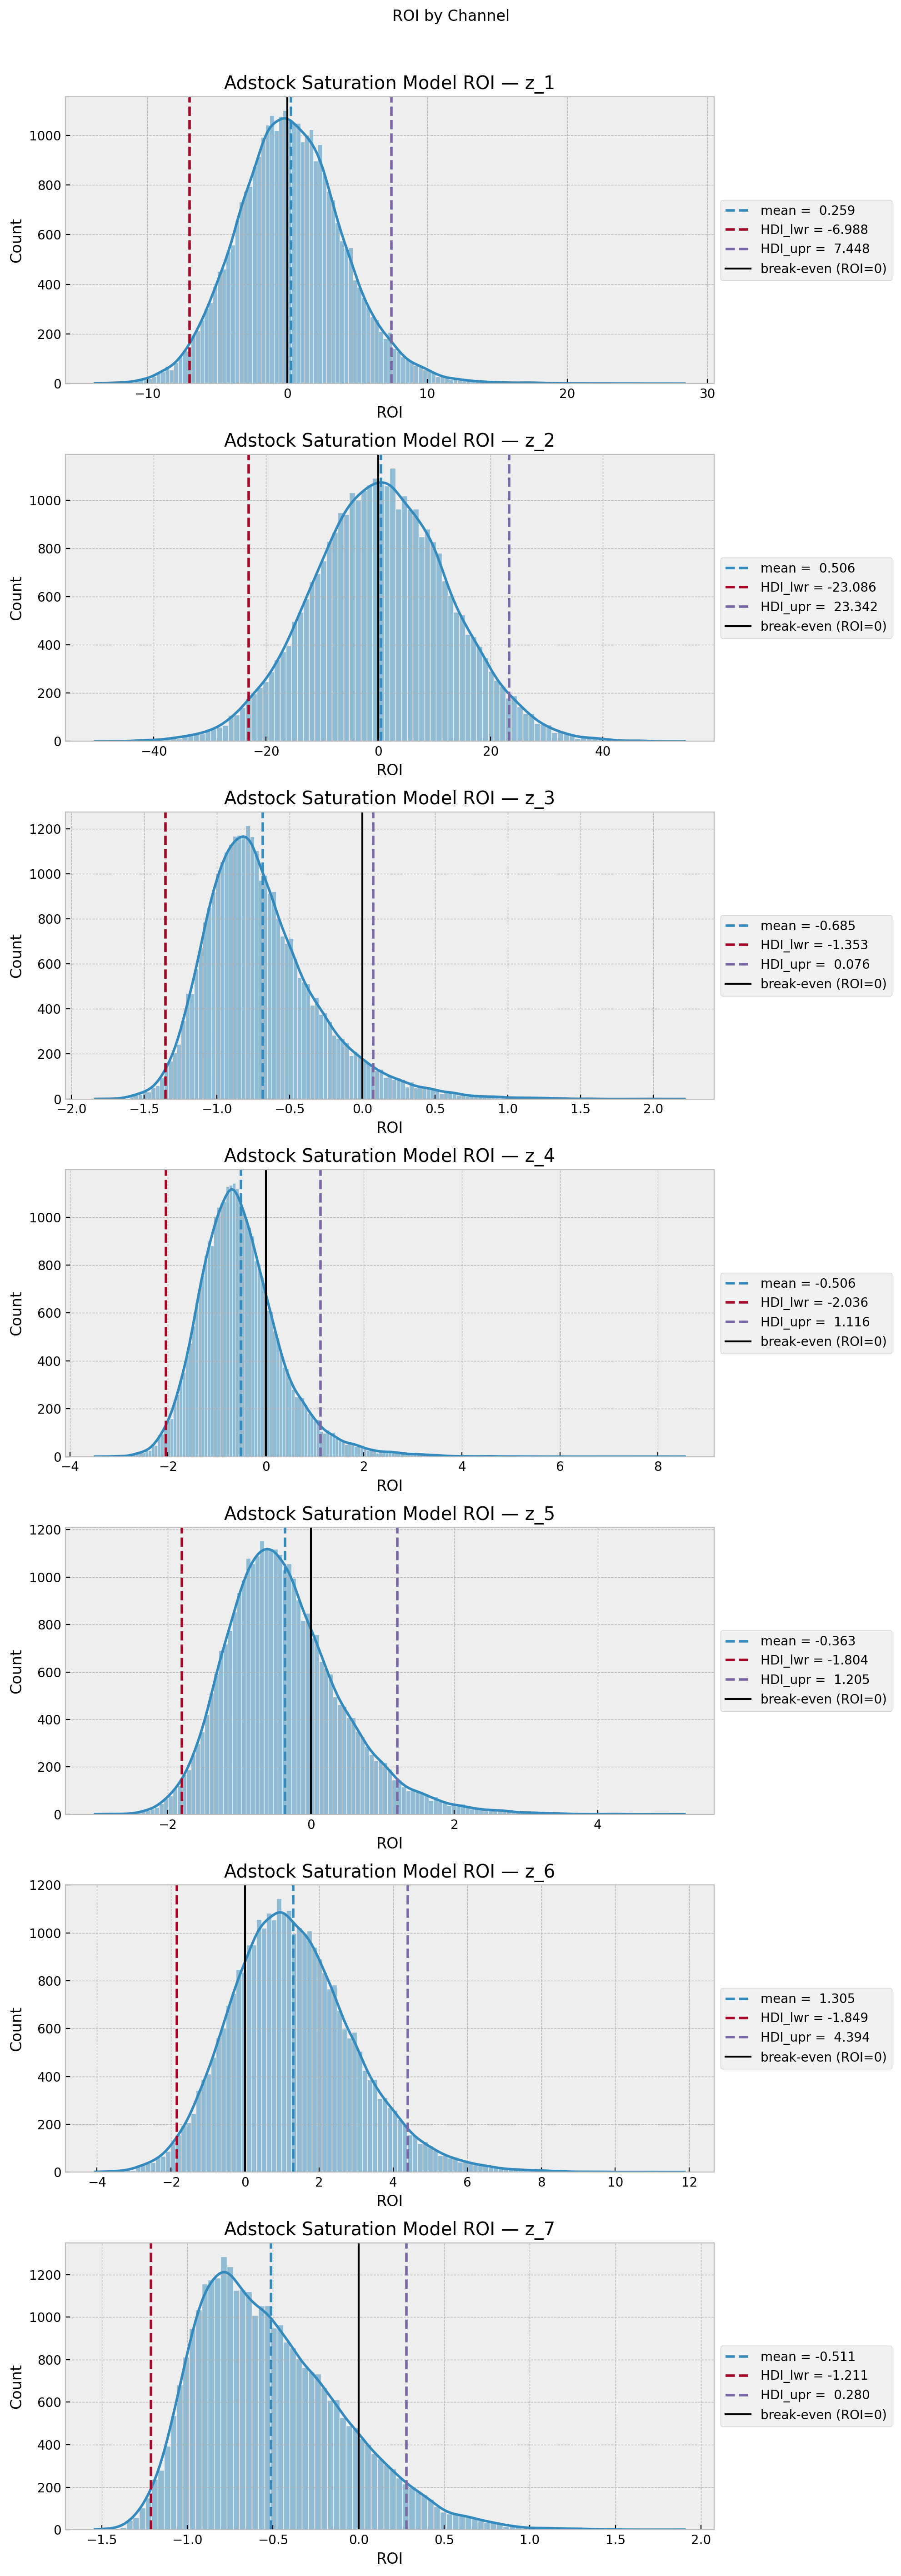

In [39]:
fig, axes = plt.subplots(7, 1, figsize=(10, 28))
for i, channel in enumerate(["z_1", "z_2", "z_3", "z_4", "z_5", "z_6", "z_7"]):
    roi_samples = roi[channel]
    roi_mean = roi_samples.mean()
    roi_hdi  = az.hdi(ary=roi_samples)
    ax = axes[i]
    sns.histplot(x=roi_samples, kde=True, ax=ax)
    ax.axvline(
        x=roi_mean,
        color="C0", linestyle="--",
        label=f"mean = {roi_mean: 0.3f}",
    )
    ax.axvline(
        x=roi_hdi[0],
        color="C1", linestyle="--",
        label=f"HDI_lwr = {roi_hdi[0]: 0.3f}",
    )
    ax.axvline(
        x=roi_hdi[1],
        color="C2", linestyle="--",
        label=f"HDI_upr = {roi_hdi[1]: 0.3f}",
    )
    ax.axvline(
        x=0, color="black", linestyle="-", linewidth=1.5, label="break-even (ROI=0)"
    )
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    ax.set(title=f"Adstock Saturation Model ROI — {channel}", xlabel="ROI")
fig.suptitle("ROI by Channel", y=1.01)
plt.tight_layout()
plt.savefig("ROI.png", dpi=150, bbox_inches="tight")
plt.show()

# Saturation of the channels

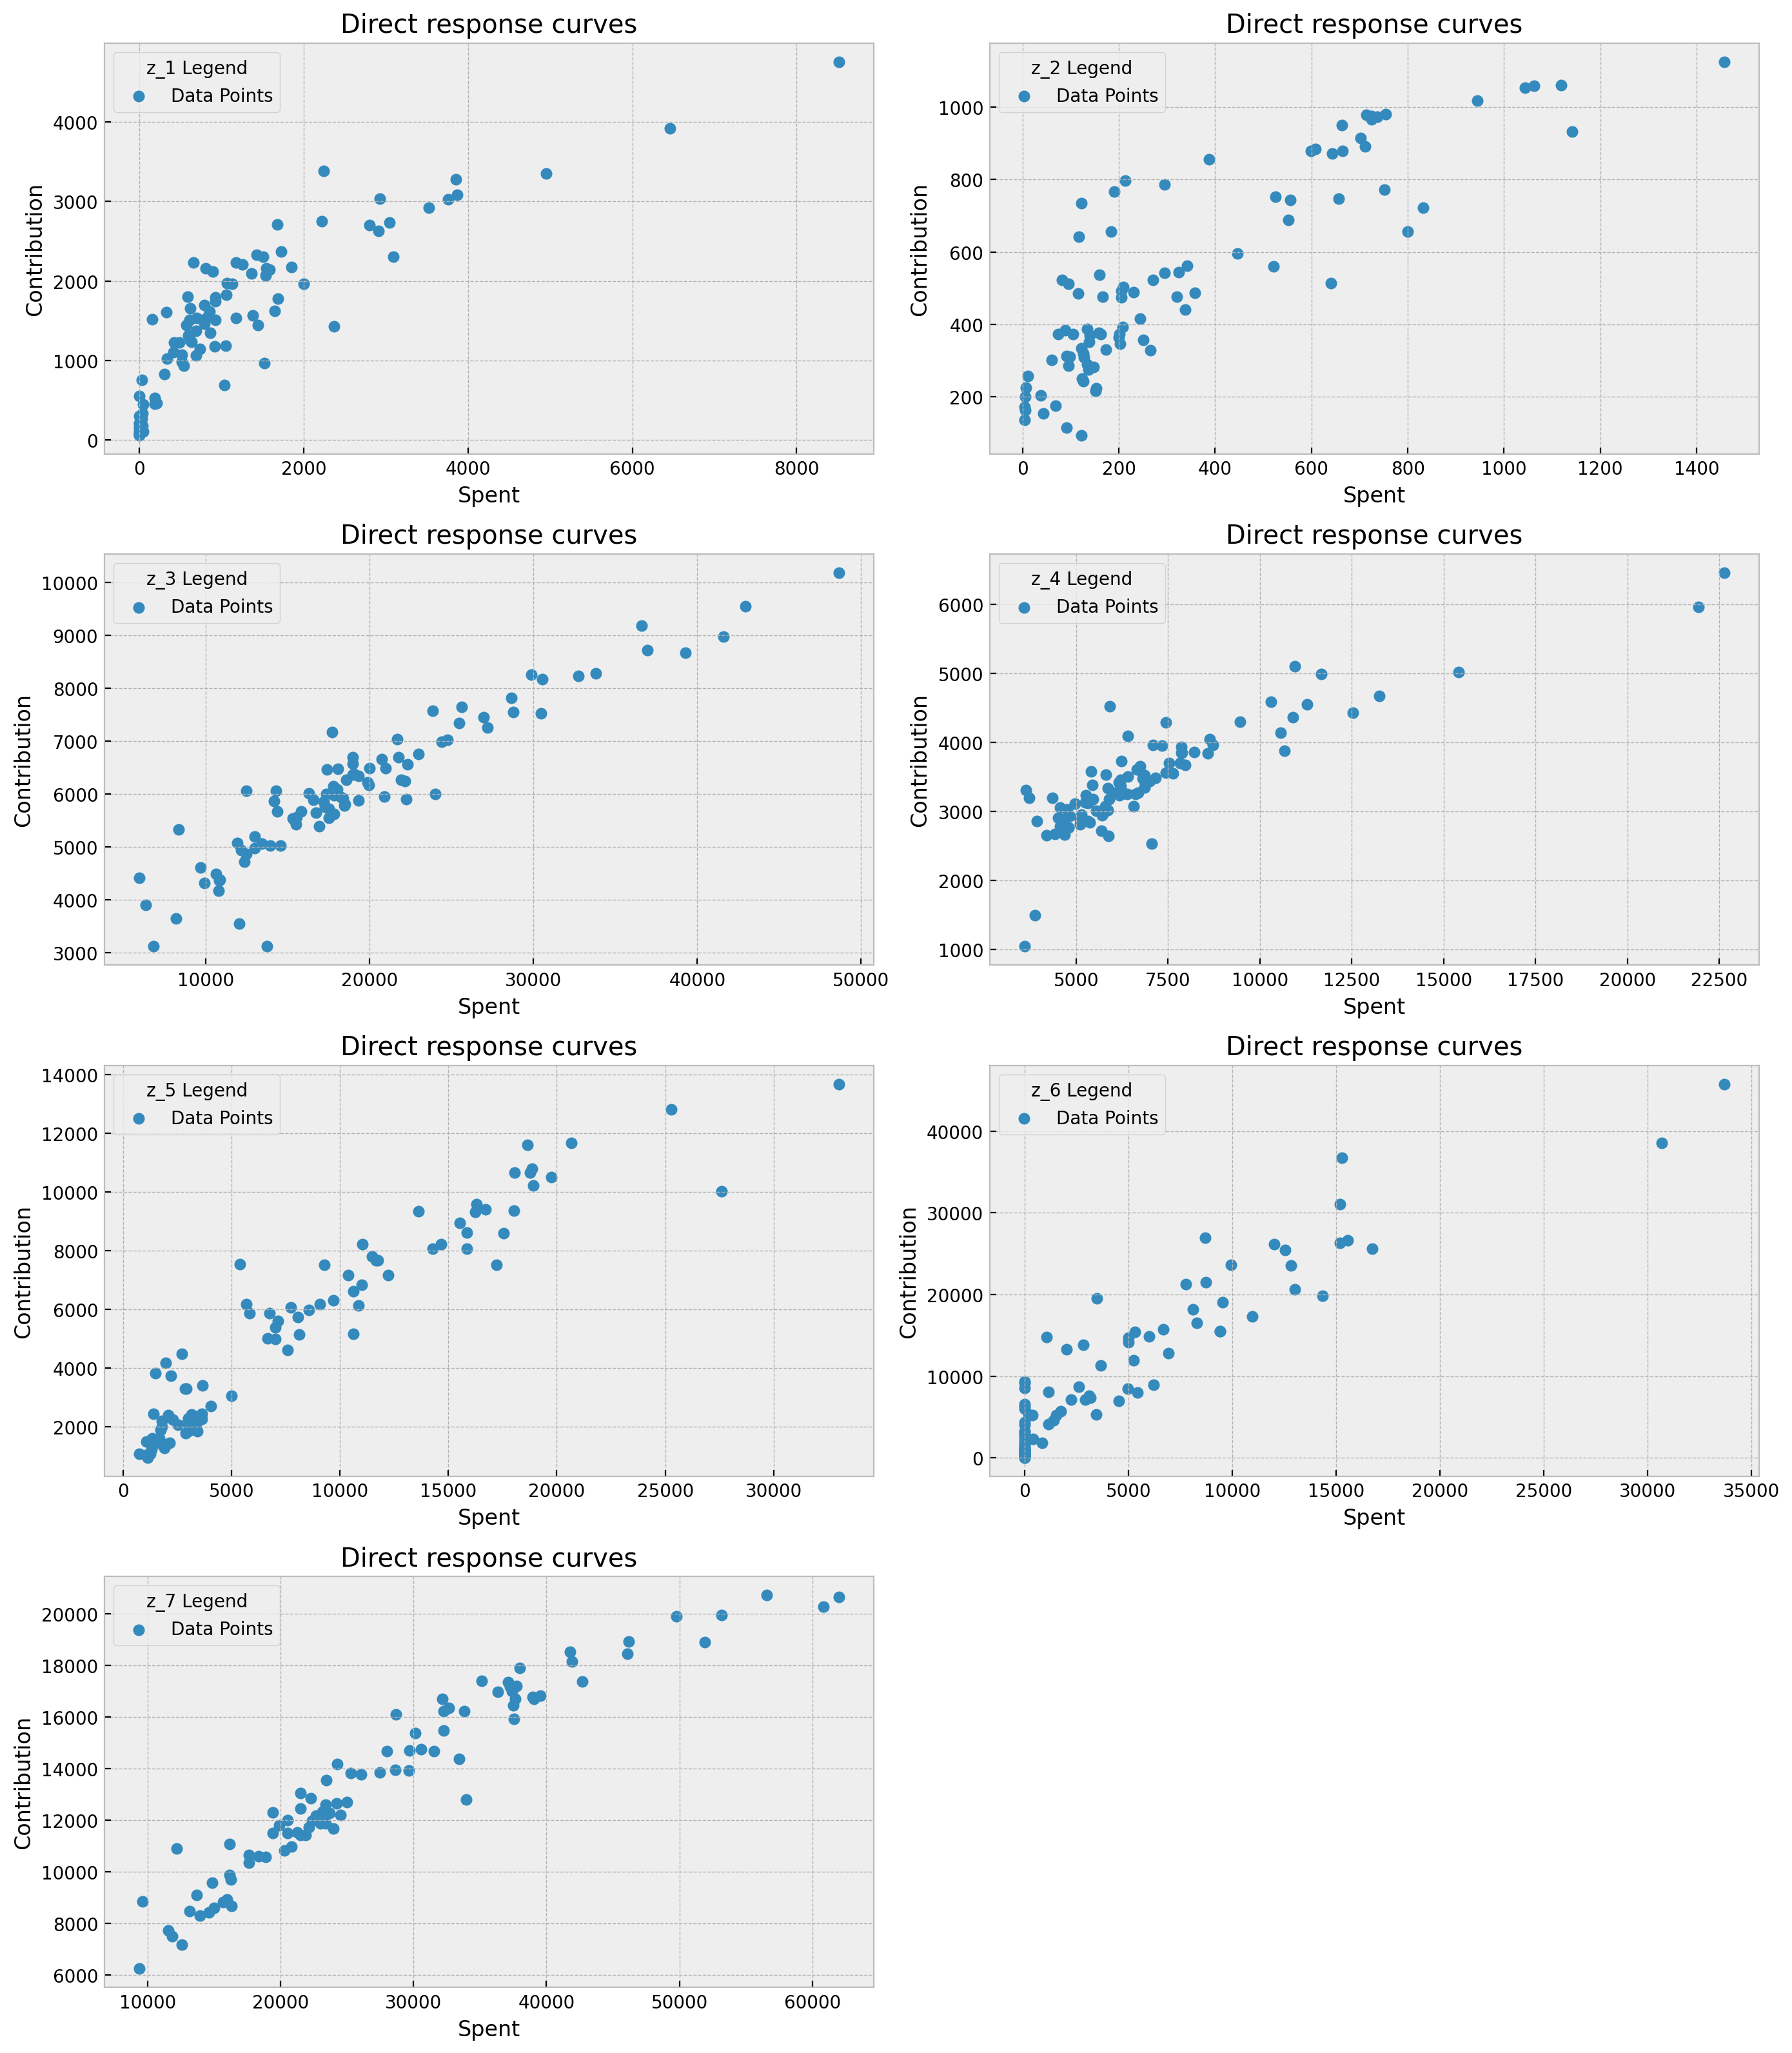

In [40]:
channels = {
    "z_1": {"effect": "z_1_effect", "spend": df["z_1"].values},
    "z_2": {"effect": "z_2_effect", "spend": df["z_2"].values},
    "z_3": {"effect": "z_3_effect", "spend": df["z_3"].values},
    "z_4": {"effect": "z_4_effect", "spend": df["z_4"].values},
    "z_5": {"effect": "z_5_effect", "spend": df["z_5"].values},
    "z_6": {"effect": "z_6_effect", "spend": df["z_6"].values},
    "z_7": {"effect": "z_7_effect", "spend": df["z_7"].values},
}

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, (channel_name, info) in enumerate(channels.items()):
    effect = az.extract(
        adstock_saturation_model_trace,
        var_names=[info["effect"]]
    ).mean(dim="sample").values

    contribution = endog_scaler.inverse_transform(effect.reshape(-1, 1)).flatten()

    axes[i].scatter(info["spend"], contribution, label="Data Points")
    axes[i].set_xlabel("Spent")
    axes[i].set_ylabel("Contribution")
    axes[i].set_title("Direct response curves")
    axes[i].legend(title=f"{channel_name} Legend")

if len(channels) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig("channel_saturations.png", dpi=150, bbox_inches="tight")
plt.show()

#### Comment: 
- The response curves also reveal which channels have room to grow versus which are hitting diminishing returns. A channel whose response curve still exhibits near-linear behaviour at its maximum observed spend level has room to grow — additional investment could yield proportional returns. Conversely, a channel whose curve is already bending (channel 7 is an obvious ) and showing clear saturation at its maximum spend level is losing effectiveness beyond that point — further investment there is increasingly wasteful. 
- In the pdf, there is an elaborate explanation on which channel to pick for future investment based on the analysis of the data and the model. 